In [31]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import re
import anndata as ad
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from itertools import groupby

os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [2]:
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/10_integration_GBM_HIHA/10_subset_macro.h5ad")
checkpoint(f"Loaded: {adata.n_obs:,} cells, {adata.n_vars:,} genes")

[2026-10-01 13:25:39] Loaded: 43,358 cells, 22,586 genes


In [3]:
OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA"

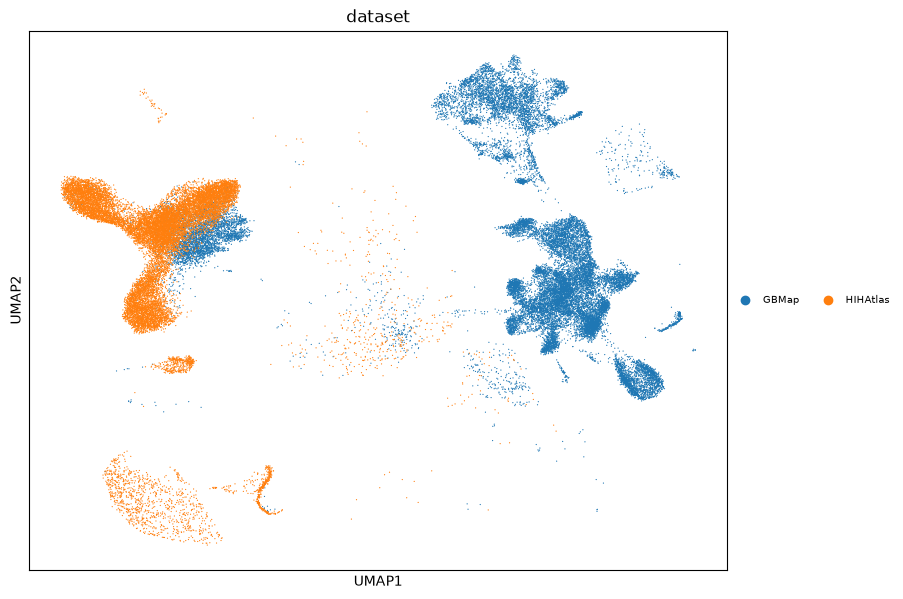

[2026-09-24 11:21:03] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_05_umap_macro_dataset.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.umap(adata, color=["dataset"], ax=ax, size=3, legend_fontsize=7, show=False)
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "10_05_umap_macro_dataset.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

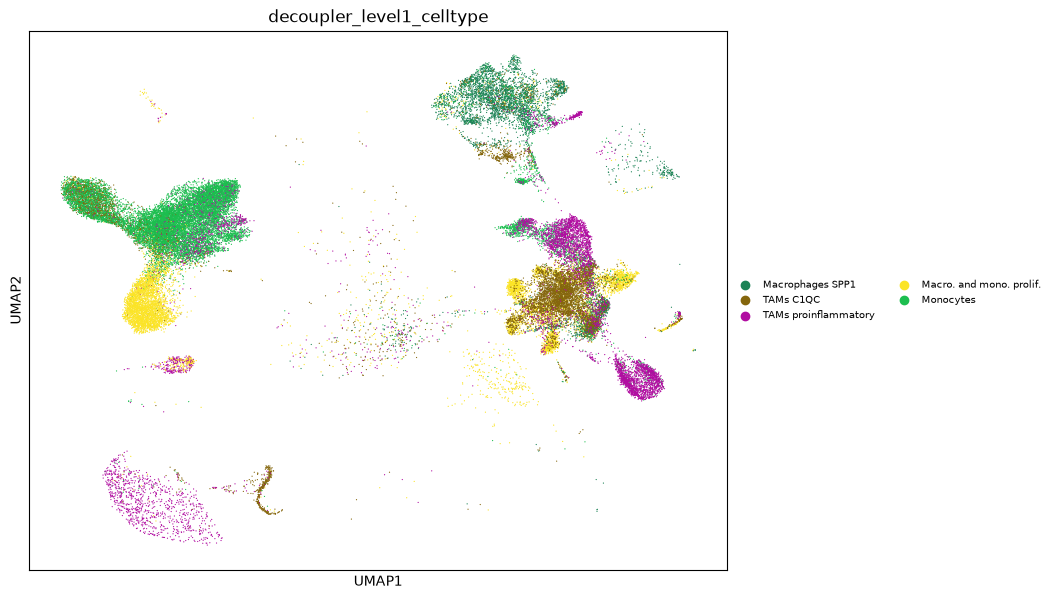

[2026-09-24 11:21:39] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_05_umap_macro_celltype.pdf


In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.umap(adata, color=["decoupler_level1_celltype"], ax=ax, size=3, legend_fontsize=7, show=False)
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "10_05_umap_macro_celltype.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

### MP scores 

In [4]:
import re
import matplotlib.pyplot as plt

BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)

In [5]:
mp_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_04_nmf_macro/mp_scores.csv", index_col=0)


In [6]:
# barcode suffix mismatch -> use intersection instead of direct .loc
common_barcodes = mp_scores.index.intersection(adata.obs_names)
n_missing = adata.n_obs - len(common_barcodes)
checkpoint(f"{len(common_barcodes)} / {adata.n_obs} adata cells matched to mp_scores "
           f"({n_missing} missing)")

[2026-10-01 13:25:39] 43358 / 43358 adata cells matched to mp_scores (0 missing)


In [23]:
SELECTED_MPS = ["MP1_score", "MP2_score", "MP3_score", "MP5_score"]

[2026-10-01 19:11:24] Plotting UMAPs


[2026-10-01 19:11:24] Plotted MP1_score
[2026-10-01 19:11:24] Plotted MP2_score
[2026-10-01 19:11:24] Plotted MP3_score
[2026-10-01 19:11:24] Plotted MP5_score


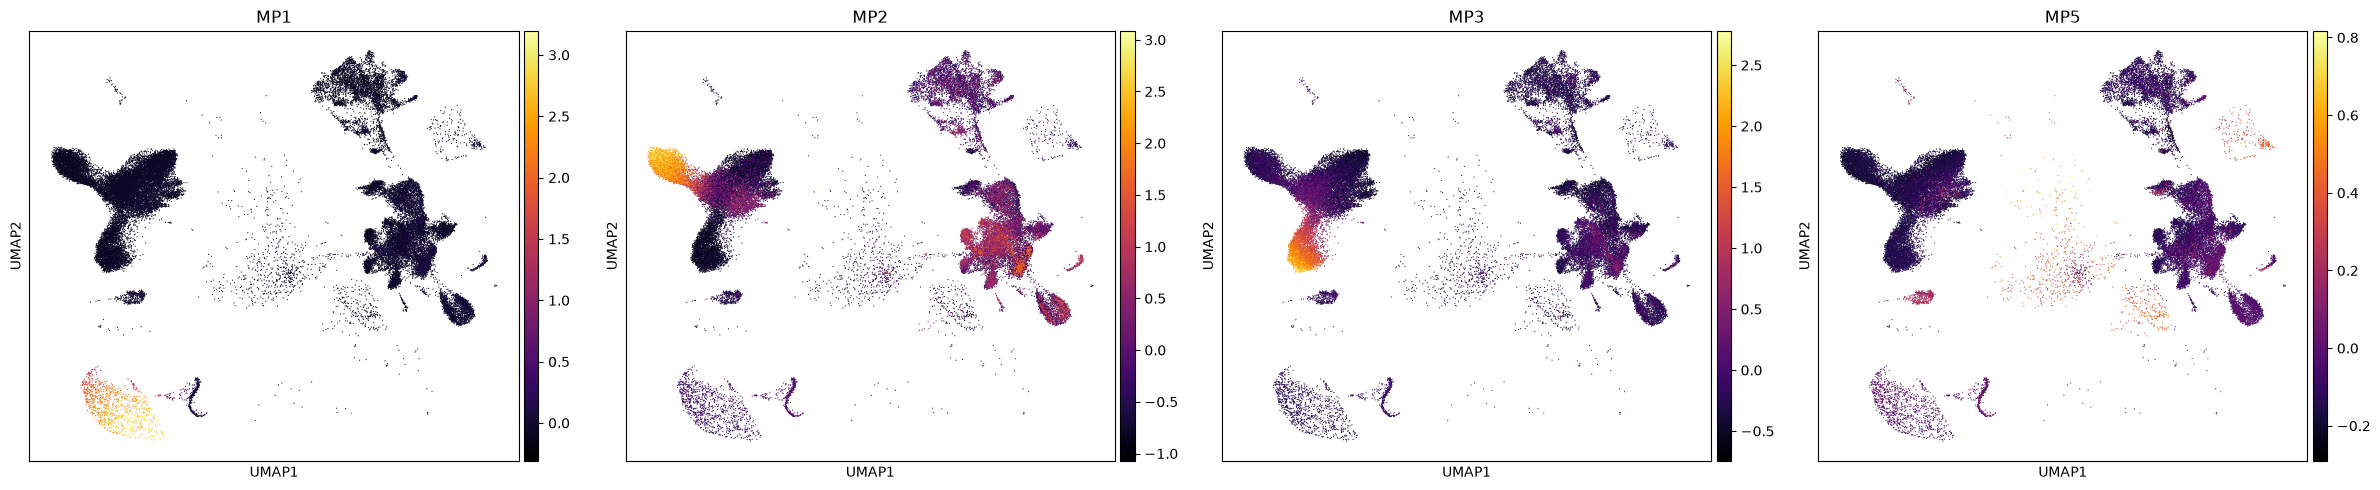

[2026-10-01 19:11:27] PDF saved


In [25]:
# align to adata.obs_names order; unmatched cells become NaN
mp_scores_aligned = mp_scores.reindex(adata.obs_names)

def mp_sort_key(name):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else 0

# ALL_MPS = sorted(mp_scores.columns.tolist(), key=mp_sort_key)

for mp in SELECTED_MPS:
    adata.obs[mp] = mp_scores_aligned[mp].values

checkpoint("Plotting UMAPs")
n_cols = 4
n_rows = -(-len(SELECTED_MPS) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, mp in enumerate(SELECTED_MPS):
    mp_name = mp.replace("_score", "")
    if mp in adata.obs.columns:
        sc.pl.umap(adata, color=mp, color_map="inferno", show=False, ax=axes[i], title=mp_name)
        axes[i].set_rasterized(True)
        checkpoint(f"Plotted {mp}")
    else:
        checkpoint(f"SKIPPED {mp} (not in adata.obs)")

# Hide empty subplots
for j in range(len(SELECTED_MPS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "10_05_umap_grid_selMP_macro.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()
checkpoint("PDF saved")

In [29]:
celltype_palette = {    
    "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
}
current_cats = set(adata.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

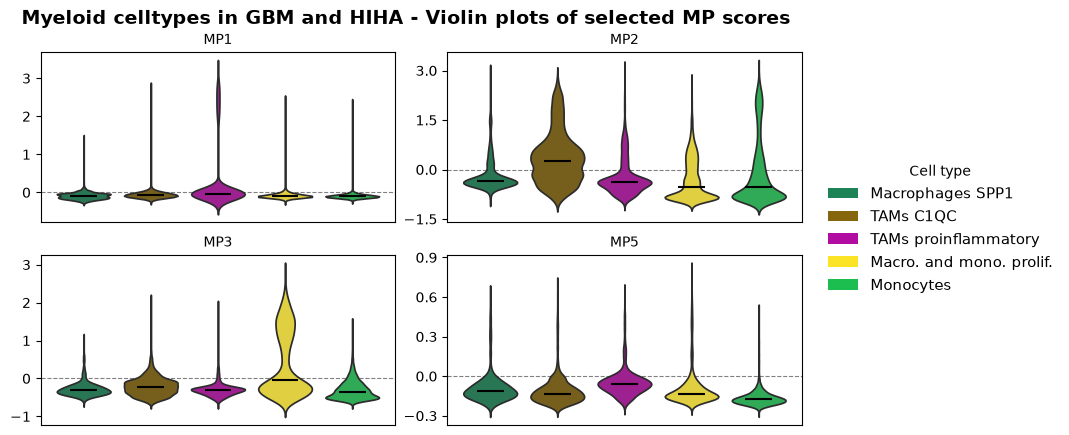

[2026-10-01 19:17:28] Combined PDF with all MP violin plots saved


In [39]:


n_mps = len(SELECTED_MPS)
n_cols = 2
n_rows = -(-n_mps // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2), constrained_layout=True)
axes = axes.flatten()

for i, mp_col in enumerate(SELECTED_MPS):
    mp_name = mp_col.replace("_score", "")
    sns.violinplot(
        data=adata.obs,
        x="decoupler_level1_celltype",
        y=mp_col,
        hue="decoupler_level1_celltype",
        palette=celltype_palette,
        order=list(celltype_palette.keys()),
        legend=False,
        ax=axes[i],
        inner=None,
    )
    medians = adata.obs.groupby("decoupler_level1_celltype", observed=True)[mp_col].median()
    medians = medians.reindex(celltype_palette.keys())
    for x_pos, med_val in enumerate(medians):
        axes[i].hlines(med_val, x_pos - 0.2, x_pos + 0.2, colors="black", linewidth=1.5, zorder=3)

    axes[i].set_title(mp_name, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xticks([])
    axes[i].axhline(0, color="grey", linestyle="--", linewidth=0.8, zorder=0)
    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5))


for j in range(n_mps, len(axes)):
    axes[j].axis("off")



legend_handles = [Patch(facecolor=color, label=ct) for ct, color in celltype_palette.items()]
fig.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.01, 0.5),fontsize=11, title="Cell type", frameon=False)
fig.suptitle("Myeloid celltypes in GBM and HIHA - Violin plots of selected MP scores", fontsize=14, y=1.05, fontweight="bold")
plt.savefig(os.path.join(OUT_DIR, "10_05_violins_selMP_per_celltype.pdf"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
checkpoint("Combined PDF with all MP violin plots saved")



### UMAP with cells assigned to MPs

In [44]:
PERCENTILE_THRESHOLD = 75
SELECTED_MPS = ["MP1", "MP2", "MP3", "MP5"]

MP_PALETTE = {
    "MP1": "#27ECDB",  # 
    "MP2": "#D340B3",  # 
    "MP3": "#FB8D26",  # 
    "MP5": "#703b3e",  # 
    "Other": "#D9D9D9",
}


In [8]:
selected_score_cols = [f"{mp}_score" for mp in SELECTED_MPS]
missing_cols = [c for c in selected_score_cols if c not in mp_scores.columns]
if missing_cols:
    raise ValueError(
        f"These expected score columns are missing from mp_scores.csv: "
        f"{missing_cols}. Available columns: {mp_scores.columns.tolist()}"
    )
 
mp_scores_aligned = mp_scores.reindex(adata.obs_names)
for col in selected_score_cols:
    adata.obs[col] = mp_scores_aligned[col].values

In [9]:
scored_mask = adata.obs[selected_score_cols].notna().any(axis=1)
scores_df = adata.obs.loc[scored_mask, selected_score_cols]
 
thresholds = {col: scores_df[col].quantile(PERCENTILE_THRESHOLD / 100) for col in selected_score_cols}
checkpoint(f"Per-MP {PERCENTILE_THRESHOLD}th percentile thresholds: {thresholds}")
 
argmax_mp = scores_df.idxmax(axis=1)
passes_threshold = pd.Series(False, index=scores_df.index)
for col in selected_score_cols:
    is_this_mp = argmax_mp == col
    passes_threshold |= is_this_mp & (scores_df[col] >= thresholds[col])
 
dominant_mp = pd.Series("Not scored", index=adata.obs_names, dtype=object)
dominant_mp.loc[scores_df.index] = "Other"
assigned_bare = argmax_mp[passes_threshold].str.replace("_score", "", regex=False)
dominant_mp.loc[scores_df.index[passes_threshold]] = assigned_bare.values
 
adata.obs["dominant_MP"] = pd.Categorical(
    dominant_mp, categories=["Not scored", "Other"] + SELECTED_MPS
)
checkpoint("Dominant MP assignment counts:")
print(adata.obs["dominant_MP"].value_counts(dropna=False))
 
# drop unused categories so the legend doesn't show empty entries
adata.obs["dominant_MP"] = adata.obs["dominant_MP"].cat.remove_unused_categories()

[2026-10-01 13:27:34] Per-MP 75th percentile thresholds: {'MP1_score': np.float64(-0.0414124123701351), 'MP2_score': np.float64(0.2949952495098113), 'MP3_score': np.float64(-0.09431430441421147), 'MP5_score': np.float64(-0.0801123537198461)}
[2026-10-01 13:27:34] Dominant MP assignment counts:
dominant_MP
Other         15881
MP2           10788
MP3            7276
MP1            5432
MP5            3981
Not scored        0
Name: count, dtype: int64


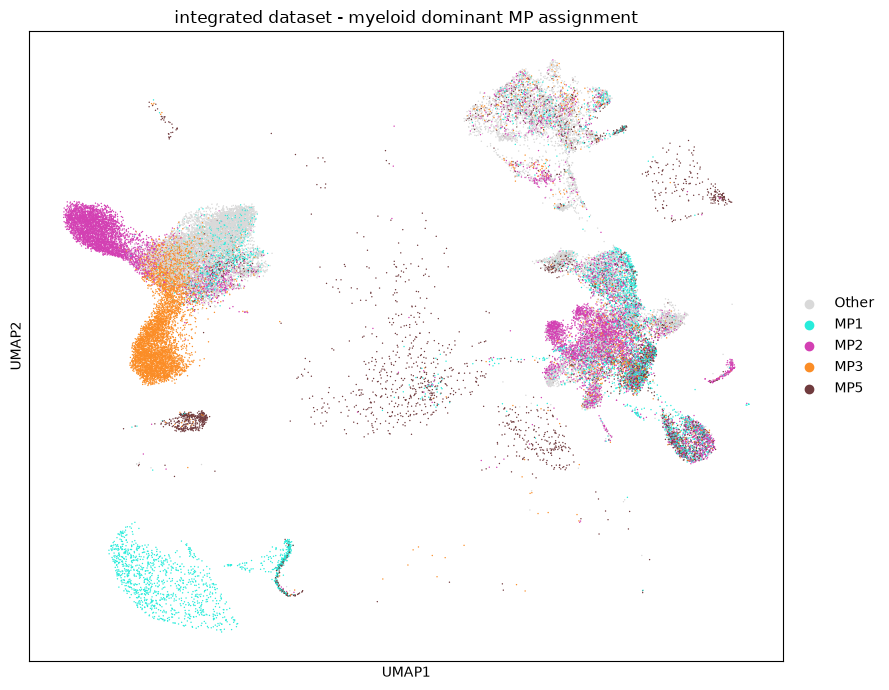

[2026-10-01 19:22:46] Saved UMAP to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_05_umap_selected_mps_assigned.pdf


In [45]:
fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(
    adata,
    color="dominant_MP",
    ax=ax,
    show=False,
    size=4,
    title="integrated dataset - myeloid dominant MP assignment",
    palette=MP_PALETTE,
)
fig.tight_layout()
 
out_pdf = os.path.join(OUT_DIR, "10_05_umap_selected_mps_assigned.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
checkpoint(f"Saved UMAP to {out_pdf}")